# Multi-phase polymorph competition under isothermal and cooling conditions

이 노트북은 Streamlit 앱의 계산 계층인 `multiphase_core.py`를 순서대로 실행하여, 다중상(polymorph) 경쟁 모델이 어떤 물리량을 연결하는지 재현한다. 기본 예시는 모상 **A**에서 시작해 자유에너지가 더 낮은 **B-F** 상으로 전이하는 6상 계를 사용한다.

핵심 아이디어는 다음 네 단계다.

1. 각 상의 자유에너지와 확산도를 온도의 함수로 계산한다.
   
   $$G_p(T)=G_p(T_{ref})+c_{G,p}(T-T_{ref}),$$

   $$D_p(T)=D_{p,ref}\exp\left[-\frac{Q_{d,p}}{k_B}\left(\frac{1}{T}-\frac{1}{T_{ref}}\right)\right].$$

2. 열역학적으로 내리막인 각 전이 $a\rightarrow b$에 대해 1차원 Becker-Doring 정상상태 flux를 계산한다.

   $$K_{ab}=\left[\sum_n\frac{1}{f_n c_n^{eq}}\right]^{-1},\qquad
   w_n=-\frac{\Delta\mu_{ab}}{k_BT}n+\gamma_{ab}n^{2/3}.$$

3. 전이율 행렬을 유향 그래프로 해석하고, 경로에서 가장 느린 간선인 bottleneck을 최대화하는 경로를 찾는다. 따라서 최적 경로는 단순히 자유에너지가 가장 급하게 감소하는 경로가 아니라, 전체 경로 중 가장 느린 단계가 가장 빠른 경로다.

4. 동일한 $K_{ab}(T)$를 평균장 분율 ODE와 다상 Allen-Cahn phase-field의 핵생성 시딩에 사용한다. 냉각 중에는 온도에 따라 전이율, 구동력, 확산도가 계속 갱신된다.

> 기본 물성값과 ODE/phase-field 계수는 prototype v3의 예시값이다. 이 노트북은 모델 구조와 kinetic selection을 재현하는 계산 예제이며, 특정 Fe polymorph의 정량 예측으로 해석하면 안 된다.

## Implementation map

| 계산 단계 | Streamlit 화면 | 실제 계산 함수 |
|---|---|---|
| 온도 의존 물성 | 입력 파라미터 | `G_at`, `D_at` |
| 전이율 행렬 | ① 전이율 · 그래프 | `transition_rate`, `build_K` |
| 경로 경쟁 | ① 전이율 · 그래프 | `analyze`, `path_bottleneck`, `plot_graph` |
| 분율 경쟁 | ② 분율 경쟁 (ODE) | `integrate_fractions`, `plot_fractions_ode` |
| 시간 보정 | ③ 미세조직 | `calibrate_time`, `v_phys` |
| 미세조직 진화 | ③ 미세조직 | `run_phase_field`, `plot_montage`, `plot_pf_fractions` |

UI 위젯은 입력값을 만드는 역할만 한다. 아래 계산은 앱과 동일한 `multiphase_core.py`를 직접 import하므로, 노트북과 배포 앱이 같은 계산 구현을 공유한다.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "notebooks",
    Path.cwd().parent.parent,
]
project_root = next(
    (path.resolve() for path in search_roots if (path / "multiphase_core.py").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "multiphase_core.py를 찾을 수 없습니다. 노트북을 repo 안에서 실행하거나 "
        "multiphase_core.py를 노트북과 같은 폴더에 두세요."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import multiphase_core as C

pd.set_option("display.max_columns", 20)
np.set_printoptions(precision=4, suppress=True)
print(f"model source: {Path(C.__file__).resolve()}")

model source: C:\Users\USER\Documents\Github_repo\.codex_notebook_staging\multiphase_core.py


## 1. Define the six-phase prototype

`PP` 객체는 상 이름, 기준 자유에너지 $G$, 원자부피 $V$, 확산도 $D$, 계면에너지 $\sigma_{ab}$, 자유에너지 온도계수 $c_G$, 확산 활성화에너지 $Q_d$를 한데 묶는다. `default_params(6)`은 Streamlit 앱의 기본 6상 예제를 그대로 만든다.

In [2]:
pp = C.default_params(6)
start_phase = "A"
target_phase = min(pp.phases, key=lambda p: pp.G[p])
T_ref = pp.T_REF

phase_table = pd.DataFrame(
    {
        "G_ref (eV/atom)": [pp.G[p] for p in pp.phases],
        "V (angstrom^3)": [pp.VOL[p] for p in pp.phases],
        "D_ref (m^2/s)": [pp.DIFF[p] for p in pp.phases],
        "cG (eV/atom/K)": [pp.cG[p] for p in pp.phases],
        "Qd (eV)": [pp.Qd[p] for p in pp.phases],
    },
    index=pd.Index(pp.phases, name="phase"),
)

sigma_table = pd.DataFrame(np.nan, index=pp.phases, columns=pp.phases)
for a in pp.phases:
    for b in pp.phases:
        if a != b:
            sigma_table.loc[a, b] = pp.SIGMA[(a, b)]

print(f"start phase = {start_phase}, lowest-G phase at T_ref = {target_phase}, T_ref = {T_ref:.0f} K")
display(phase_table)
display(sigma_table.style.format("{:.3f}").set_caption("Interfacial energy sigma_ab (J/m^2)"))

start phase = A, lowest-G phase at T_ref = F, T_ref = 160 K


,G_ref (eV/atom),V (angstrom^3),D_ref (m^2/s),cG (eV/atom/K),Qd (eV)
phase,,,,,
A,0.000,11.5,1.300000e-15,0.00000,0.10
B,-0.030,11.8,1.600000e-13,0.00010,0.08
C,-0.050,12.0,1.000000e-13,0.00020,0.09
D,-0.070,11.7,8.000000e-14,0.00015,0.10
E,-0.085,12.1,5.000000e-14,0.00025,0.12
F,-0.100,11.6,3.000000e-15,0.00060,0.15


,A,B,C,D,E,F
A,nan,0.050,0.090,0.130,0.165,0.210
B,0.050,nan,0.055,0.085,0.125,0.170
C,0.090,0.055,nan,0.060,0.095,0.135
D,0.130,0.085,0.060,nan,0.058,0.088
E,0.165,0.125,0.095,0.058,nan,0.052
F,0.210,0.170,0.135,0.088,0.052,nan


## 2. Inspect temperature-dependent free energies and diffusivities

냉각 과정에서 자유에너지 순서와 확산 속도가 동시에 변한다. 낮은 자유에너지는 전이의 열역학적 방향과 구동력을 정하고, 모상 쪽 확산도는 Turnbull-Fisher 부착률을 통해 $K_{ab}$의 시간 척도를 정한다.

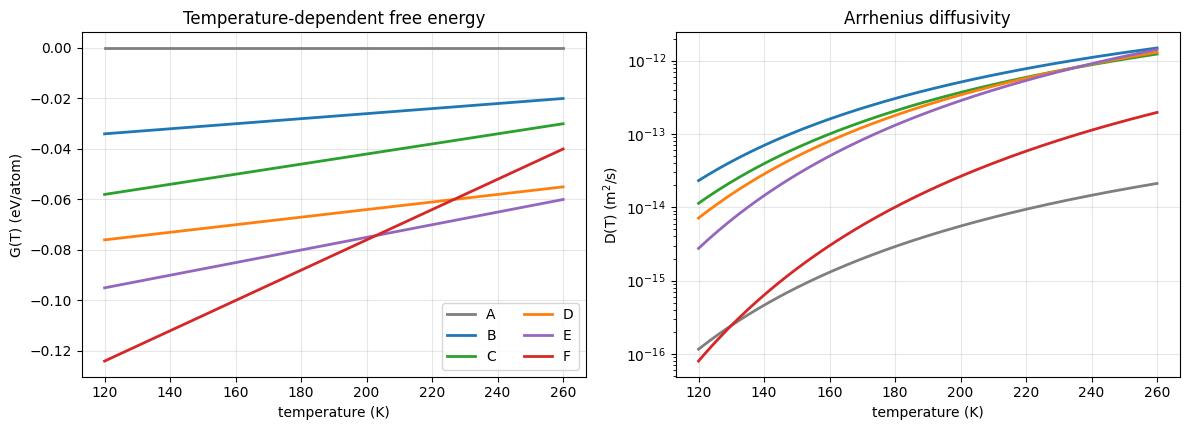

In [3]:
temperature_grid = np.linspace(120.0, 260.0, 141)
G_vs_T = pd.DataFrame(
    [{"T (K)": T, **C.G_at(pp, T)} for T in temperature_grid]
).set_index("T (K)")
D_vs_T = pd.DataFrame(
    [{"T (K)": T, **C.D_at(pp, T)} for T in temperature_grid]
).set_index("T (K)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for phase in pp.phases:
    axes[0].plot(G_vs_T.index, G_vs_T[phase], color=pp.color[phase], lw=2, label=phase)
    axes[1].semilogy(D_vs_T.index, D_vs_T[phase], color=pp.color[phase], lw=2, label=phase)
axes[0].set(xlabel="temperature (K)", ylabel="G(T) (eV/atom)", title="Temperature-dependent free energy")
axes[1].set(xlabel="temperature (K)", ylabel="D(T) (m$^2$/s)", title="Arrhenius diffusivity")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(ncol=2)
fig.tight_layout()
display(fig)
plt.close(fig)

## 3. Build the transition-rate matrix and find competing paths

기준 온도에서 모든 상 쌍을 검사해 $G_a(T)>G_b(T)$인 내리막 전이만 허용한다. 각 행은 출발 상, 각 열은 도착 상이며 0은 열역학적으로 허용되지 않거나 자기 전이인 경우다.

한 경로의 유효 속도는 그 경로의 최소 $K_{ab}$로 정의한다. `analyze`는 가능한 단순 경로를 열거하고 bottleneck이 큰 순서로 정렬한다.

In [4]:
K_ref = C.build_K(pp, T_ref)
path_results = C.analyze(pp, K_ref, start_phase)

K_table = pd.DataFrame(K_ref, index=pp.phases, columns=pp.phases).replace(0.0, np.nan)
path_rows = []
for target in pp.phases:
    if target == start_phase or not path_results.get(target):
        continue
    best = path_results[target][0]
    path_rows.append(
        {
            "target": target,
            "best path": " -> ".join(best["path"]),
            "bottleneck (m^-3 s^-1)": best["bottleneck"],
            "limiting edge": " -> ".join(best["bn_edge"]),
            "number of routes": len(path_results[target]),
        }
    )

best_to_target = path_results[target_phase][0]
display(K_table.style.format("{:.2e}", na_rep="-").set_caption(f"K_ab at {T_ref:.0f} K (row a -> column b)"))
display(pd.DataFrame(path_rows).style.format({"bottleneck (m^-3 s^-1)": "{:.2e}"}))

,A,B,C,D,E,F
A,-,2.07e+33,8.61e+31,6.03e+30,2.88e+28,4.86e+25
B,-,-,6.49e+30,4.37e+32,9.31e+28,2.48e+25
C,-,-,-,1.04e+29,6.39e+26,2.38e+24
D,-,-,-,-,1.76e+22,2.86e+26
E,-,-,-,-,-,1.33e+27
F,-,-,-,-,-,-


,target,best path,bottleneck (m^-3 s^-1),limiting edge,number of routes
0,B,A -> B,2.07e+33,A -> B,1
1,C,A -> C,8.61e+31,A -> C,2
2,D,A -> B -> D,4.37e+32,B -> D,4
3,E,A -> B -> E,9.31e+28,B -> E,8
4,F,A -> B -> E -> F,1.33e+27,E -> F,16


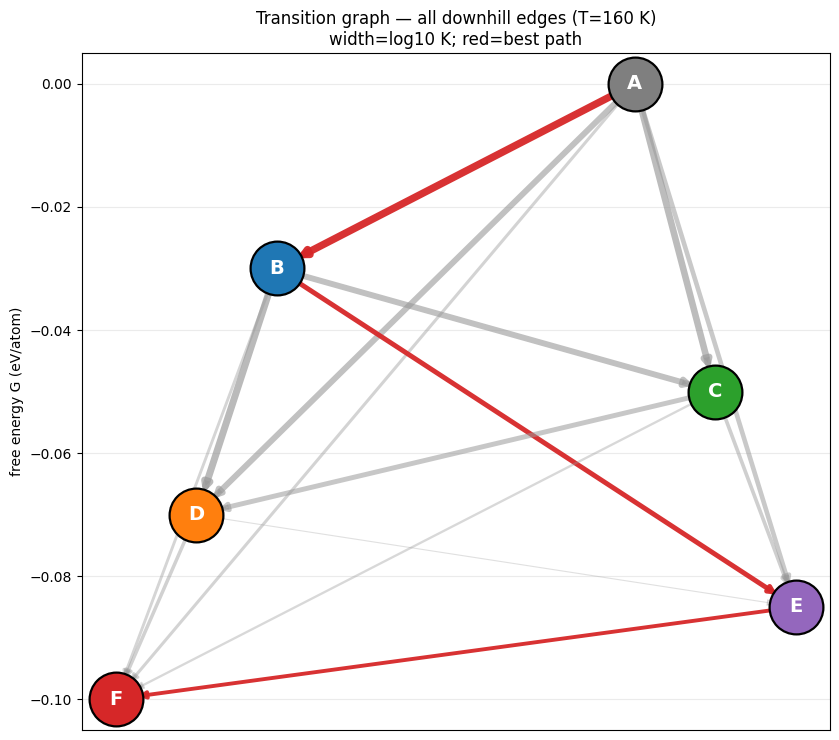

In [5]:
fig_graph = C.plot_graph(pp, K_ref, best_to_target, T_ref)
display(fig_graph)
plt.close(fig_graph)

## 4. Follow the fastest path as temperature changes

동일한 상 조합이라도 $G(T)$와 $D(T)$가 달라지므로 각 간선의 전이율과 전체 경로의 bottleneck도 온도에 따라 달라진다. 아래 계산은 각 온도에서 A에서 F로 가는 최적 경로를 다시 찾는다. 선은 최적 경로의 가장 느린 단계가 갖는 속도이며, 표의 `best path` 변화는 온도가 kinetic route selection을 바꿀 수 있음을 보여준다.

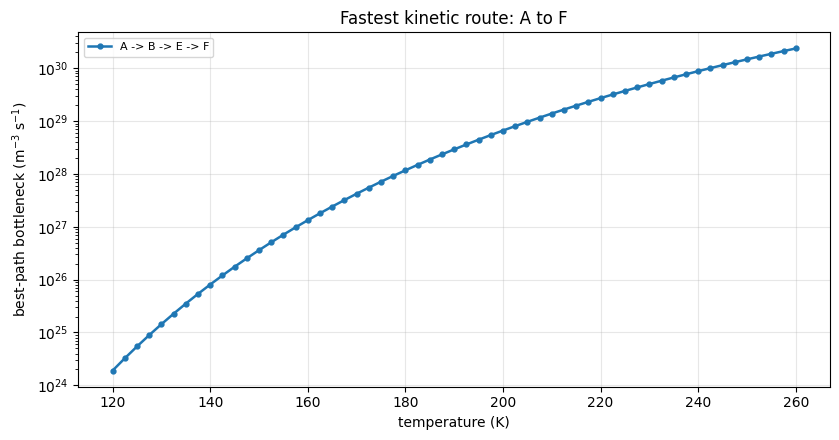

,T (K),bottleneck,best path,limiting edge
0,120.0,1.90e+24,A -> B -> E -> F,E -> F
1,140.0,8.08e+25,A -> B -> E -> F,E -> F
2,160.0,1.33e+27,A -> B -> E -> F,E -> F
3,180.0,1.17e+28,A -> B -> E -> F,E -> F
4,200.0,6.64e+28,A -> B -> E -> F,E -> F
5,220.0,2.73e+29,A -> B -> E -> F,E -> F
6,240.0,8.83e+29,A -> B -> E -> F,E -> F
7,260.0,2.38e+30,A -> B -> E -> F,E -> F


In [6]:
scan_rows = []
for T in np.linspace(120.0, 260.0, 57):
    K_T = C.build_K(pp, T)
    candidates = C.analyze(pp, K_T, start_phase).get(target_phase, [])
    if candidates:
        best = candidates[0]
        scan_rows.append(
            {
                "T (K)": T,
                "bottleneck": best["bottleneck"],
                "best path": " -> ".join(best["path"]),
                "limiting edge": " -> ".join(best["bn_edge"]),
            }
        )

path_scan = pd.DataFrame(scan_rows)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for path_name, group in path_scan.groupby("best path"):
    ax.semilogy(group["T (K)"], group["bottleneck"], "o-", ms=3.5, lw=1.8, label=path_name)
ax.set(xlabel="temperature (K)", ylabel="best-path bottleneck (m$^{-3}$ s$^{-1}$)", title=f"Fastest kinetic route: {start_phase} to {target_phase}")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)
display(path_scan.iloc[::8].reset_index(drop=True).style.format({"T (K)": "{:.1f}", "bottleneck": "{:.2e}"}))

## 5. Integrate the non-isothermal phase-fraction ODE

평균장 모델은 핵생성과 성장 항을 합친 전이 행렬로 상분율 벡터를 적분한다.

$$\dot{\boldsymbol\phi}=\mathbf{T}(\boldsymbol\phi,T)\boldsymbol\phi.$$

핵생성 계수는 정규화된 $K_{ab}$에 비례하고, 성장 계수는 $\Delta\mu_{ab}D_a$에 비례한다. 아래에서는 260 K에서 120 K까지 선형 냉각하며, 매 구간의 중간 온도에서 계수를 다시 만든다. ODE의 시간은 앱과 마찬가지로 arbitrary units이다.

,phase,final fraction
4,E,0.992534
5,F,0.007460
0,A,0.000007
1,B,0.000000
2,C,0.000000
3,D,0.000000


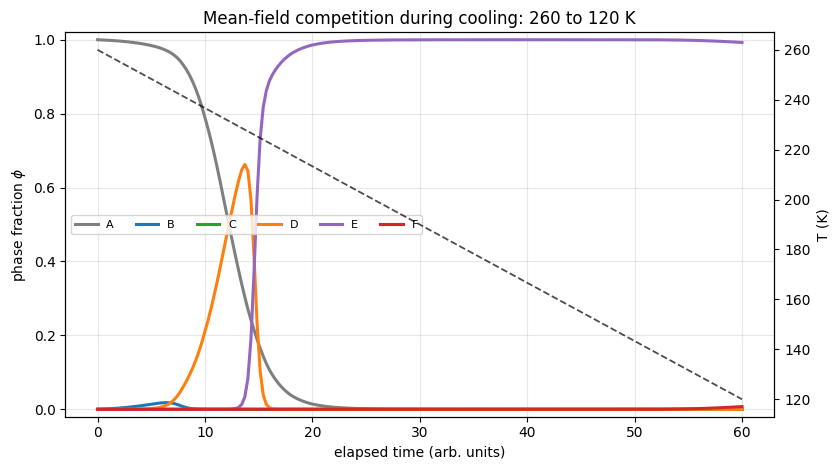

In [7]:
T_hot_ode, T_cold_ode = 260.0, 120.0
t_total_ode, n_segments = 60.0, 30
nu0, g0 = 2.0e-3, 2.5

def cooling_profile(t):
    return T_hot_ode + (T_cold_ode - T_hot_ode) * (np.asarray(t) / t_total_ode)


ode_time, ode_fraction = C.integrate_fractions(
    pp,
    cooling_profile,
    t_total=t_total_ode,
    n_seg=n_segments,
    nu0=nu0,
    g0=g0,
    start=start_phase,
    n_sub=8,
)
ode_temperature = cooling_profile(ode_time)
ode_final = pd.DataFrame(
    {"phase": pp.phases, "final fraction": ode_fraction[-1]}
).sort_values("final fraction", ascending=False)

display(ode_final.style.format({"final fraction": "{:.6f}"}))
fig_ode = C.plot_fractions_ode(
    pp,
    ode_time,
    ode_fraction,
    title=f"Mean-field competition during cooling: {T_hot_ode:.0f} to {T_cold_ode:.0f} K",
    T_vals=ode_temperature,
)
display(fig_ode)
plt.close(fig_ode)

## 6. Run the time-calibrated multi-phase field model

미세조직 층은 여러 order parameter를 갖는 Allen-Cahn 방정식을 적분하고, 현재 우세상에서 더 낮은 자유에너지 상으로의 핵생성을 $K_{ab}$ 비율에 따른 Poisson 시딩으로 넣는다.

시뮬레이션 시간은 대표 전이 A$\rightarrow$F의 1차원 계면 속도를 Turnbull-Fisher 물리 속도와 맞춰 보정한다. 이 보정은 물리시간의 차수(order of magnitude)를 제공하지만, 모든 상 쌍의 계면 mobility를 독립적으로 검증한 것은 아니다.

Streamlit 기본값은 `nx=96`, `steps=300`이다. 저장소에서 빠르게 재실행할 수 있도록 이 노트북은 `nx=64`, `steps=150`의 검증용 계산을 사용한다.

In [8]:
T_hot_pf, T_cold_pf = 240.0, 140.0
T_cal = 0.5 * (T_hot_pf + T_cold_pf)
dx = 1.0e-9

seconds_per_sim_time, seed_coefficient, calibration = C.calibrate_time(
    pp, start_phase, target_phase, T_cal, dx=dx
)

frames, recorded_steps, pf_fraction, pf_time, pf_temperature = C.run_phase_field(
    pp,
    T_hot=T_hot_pf,
    T_cold=T_cold_pf,
    start=start_phase,
    nx=64,
    steps=150,
    seed_C=seed_coefficient,
    rng_seed=1,
    record_every=8,
)

calibration_table = pd.DataFrame(
    {
        "value": {
            "v_sim (cells/step)": calibration["v_sim"],
            "v_phys (m/s)": calibration["v_phys"],
            "dx (m/cell)": calibration["dx"],
            "time (microsecond/step)": calibration["us_per_step"],
            "total physical time (ms)": pf_time[-1] * seconds_per_sim_time * 1e3,
            "seed coefficient": seed_coefficient,
        }
    }
)
pf_final = pd.DataFrame(
    {"phase": pp.phases, "final area fraction": pf_fraction[-1]}
).sort_values("final area fraction", ascending=False)

display(calibration_table.style.format("{:.4e}"))
display(pf_final.style.format({"final area fraction": "{:.6f}"}))

,value
v_sim (cells/step),3.0460e-01
v_phys (m/s),1.6234e-05
dx (m/cell),1.0000e-09
time (microsecond/step),1.8763e+01
total physical time (ms),2.7956e+00
seed coefficient,3.1271e-31


,phase,final area fraction
3,D,0.787354
5,F,0.212646
0,A,0.000000
1,B,0.000000
2,C,0.000000
4,E,0.000000


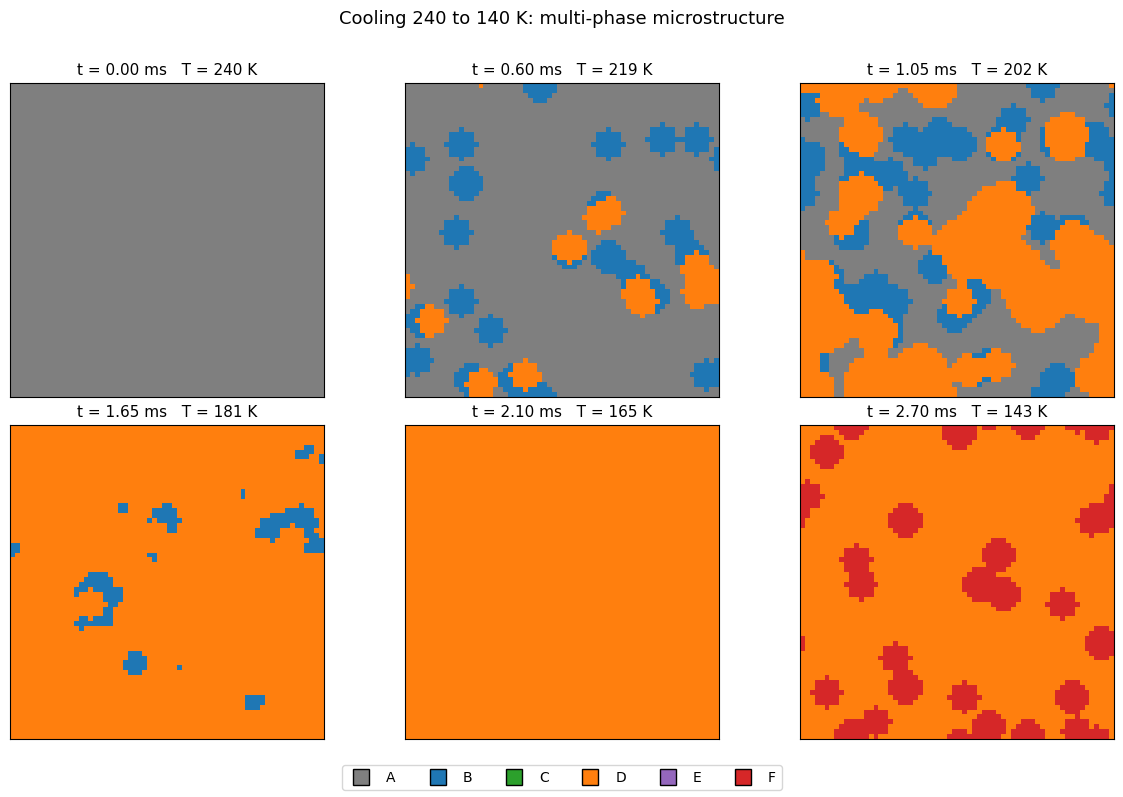

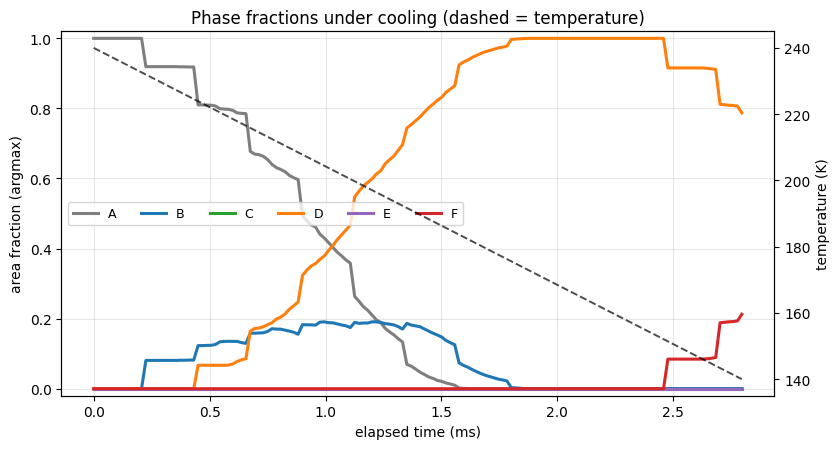

In [9]:
fig_montage = C.plot_montage(
    pp,
    frames,
    recorded_steps,
    pf_time,
    pf_temperature,
    seconds_per_sim_time,
    title=f"Cooling {T_hot_pf:.0f} to {T_cold_pf:.0f} K: multi-phase microstructure",
)
display(fig_montage)
plt.close(fig_montage)

fig_pf_fraction = C.plot_pf_fractions(
    pp, pf_fraction, pf_time, pf_temperature, seconds_per_sim_time
)
display(fig_pf_fraction)
plt.close(fig_pf_fraction)

## 7. Compact numerical summary

세 계산 층은 같은 온도 의존 물성과 전이율 모델을 공유하지만, 서로 다른 질문에 답한다.

- 경로 그래프: 현재 온도에서 어떤 순차 전이가 가장 빠른가?
- 분율 ODE: 공간을 평균했을 때 냉각 이력 아래 어느 상이 우세해지는가?
- phase field: 핵생성과 계면 이동이 공간적으로 경쟁할 때 어떤 미세조직과 면적분율이 나타나는가?

ODE와 phase field의 최종 우세상이 반드시 같을 필요는 없다. 공간 상관, 유한 핵생성 사건, 대표 전이에 의한 시간 보정, 서로 다른 계수의 근사 때문에 두 층은 같은 $K_{ab}$를 사용하면서도 다른 coarse-graining을 나타낸다.

In [10]:
summary = pd.DataFrame(
    [
        {
            "quantity": "best path at T_ref",
            "result": " -> ".join(best_to_target["path"]),
        },
        {
            "quantity": "bottleneck at T_ref (m^-3 s^-1)",
            "result": f"{best_to_target['bottleneck']:.3e}",
        },
        {
            "quantity": "ODE dominant phase after cooling",
            "result": ode_final.iloc[0]["phase"],
        },
        {
            "quantity": "phase-field dominant phase after cooling",
            "result": pf_final.iloc[0]["phase"],
        },
        {
            "quantity": "phase-field physical duration (ms)",
            "result": f"{pf_time[-1] * seconds_per_sim_time * 1e3:.4f}",
        },
    ]
)
display(summary)

,quantity,result
0,best path at T_ref,A -> B -> E -> F
1,bottleneck at T_ref (m^-3 s^-1),1.335e+27
2,ODE dominant phase after cooling,E
3,phase-field dominant phase after cooling,D
4,phase-field physical duration (ms),2.7956


## 8. Reproducibility and limitations

- 계산 소스: `multiphase_core.py` (Streamlit 배포 앱과 동일 파일)
- 기본 난수 시드: `rng_seed=1`
- 전이율: 1D 정상상태 master-equation flux와 Turnbull-Fisher 부착률
- ODE 시간: arbitrary units; `nu0`, `g0`는 예시 prefactor
- phase-field 시간: A$\rightarrow$F 한 대표 계면의 속도로 보정한 차수 수준의 물리시간
- 기본 물성: Fe-like 예시값이며 정량 재료 예측에는 실험/계산 기반 $G(T)$, $D(T)$, $\sigma_{ab}$, mobility 보정이 필요

애니메이션이 필요하면 마지막 계산 뒤에 아래 코드를 별도로 실행할 수 있다.

```python
gif_bytes = C.montage_gif_bytes(
    pp, frames, recorded_steps, pf_time, pf_temperature, seconds_per_sim_time
)
Path("multiphase_microstructure.gif").write_bytes(gif_bytes)
```